# 03 — Dupire Local Volatility

Reference: Hagan et al. (2002) §2 / eq. (2.8); Dupire (1994).

**Local-vol model:** $dF_t = \sigma_{loc}(F_t)\,F_t\,dW$.

**Dupire's formula (in terms of implied variance $w(K,T) = \sigma^2(K,T)\,T$ and log-moneyness $y = \ln(K/F)$):**

$$ \sigma_{loc}^2(K,T) = \frac{\partial w / \partial T}{1 - \tfrac{y}{w}\partial_y w + \tfrac14\!\left(-\tfrac14 - \tfrac1w + \tfrac{y^2}{w^2}\right)(\partial_y w)^2 + \tfrac12 \partial_{yy} w}. $$

Local vol perfectly re-prices today's smile but its dynamics are the **wrong way round** — Hagan's figures 2.2–2.4: when $F$ rises, the model shifts the smile down, whereas the market shifts it up. This is exactly the motivation on slide 4 of the outline.

In [1]:
# allow importing from ../src
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (7, 4.5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})


In [2]:
from src.sabr import sabr_vol
from src.local_vol import dupire_local_vol

## Test 1 — Flat Black-Scholes surface recovers $\sigma_{loc} = \sigma$

In [3]:
F = 100.0
Ks = np.linspace(70, 130, 41)
Ts = np.linspace(0.1, 2.0, 20)
flat = np.full((len(Ts), len(Ks)), 0.20)
sloc = dupire_local_vol(flat, Ks, Ts, F)
interior = sloc[1:-1, 1:-1]
print(f'interior local vol: mean = {np.nanmean(interior):.6f}, '
      f'std = {np.nanstd(interior):.2e}')
assert abs(np.nanmean(interior) - 0.20) < 1e-6

interior local vol: mean = 0.200000, std = 8.09e-17


## Test 2 — Dupire applied to a SABR-generated surface

Take a SABR surface as the "market" and extract its local-vol image. This is the surface that a Local-Vol model would need to use in order to re-price the SABR smile exactly today.

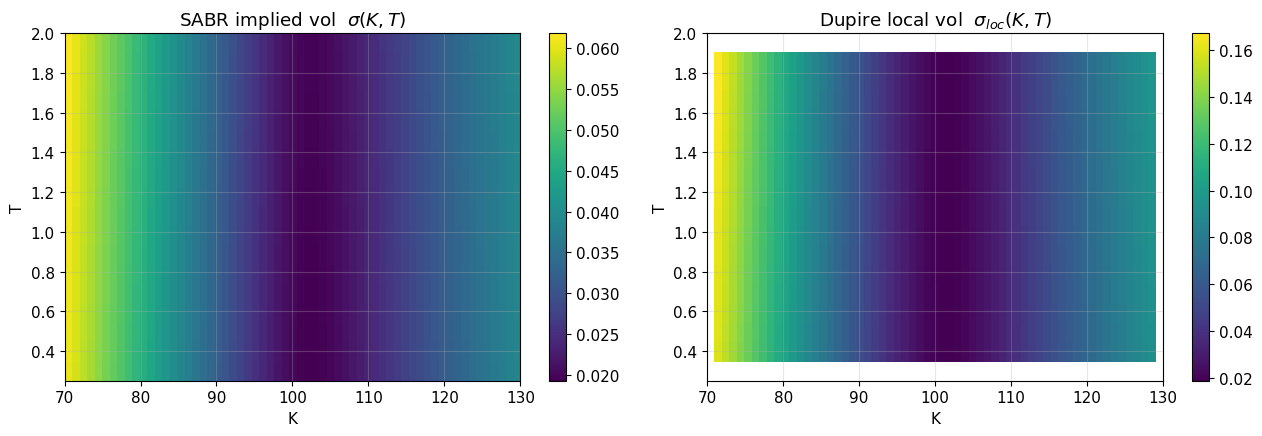

In [4]:
T0 = 1.0
alpha0, beta0, rho0, nu0 = 0.20, 0.5, -0.30, 0.40

Ks = np.linspace(70, 130, 61)
Ts = np.linspace(0.25, 2.0, 18)

iv_surface = np.array([sabr_vol(Ks, F, T_, alpha0, beta0, rho0, nu0) for T_ in Ts])
sloc = dupire_local_vol(iv_surface, Ks, Ts, F)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
im0 = ax[0].imshow(iv_surface, aspect='auto', origin='lower',
                   extent=[Ks[0], Ks[-1], Ts[0], Ts[-1]])
ax[0].set_title(r'SABR implied vol  $\sigma(K,T)$')
ax[0].set_xlabel('K'); ax[0].set_ylabel('T')
plt.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(sloc, aspect='auto', origin='lower',
                   extent=[Ks[0], Ks[-1], Ts[0], Ts[-1]])
ax[1].set_title(r'Dupire local vol  $\sigma_{loc}(K,T)$')
ax[1].set_xlabel('K'); ax[1].set_ylabel('T')
plt.colorbar(im1, ax=ax[1])
plt.tight_layout(); plt.show()

### Slice at a fixed $T$: local-vol skew ≈ **twice** implied-vol skew
This is the well-known Dupire rule of thumb (Hagan §2).

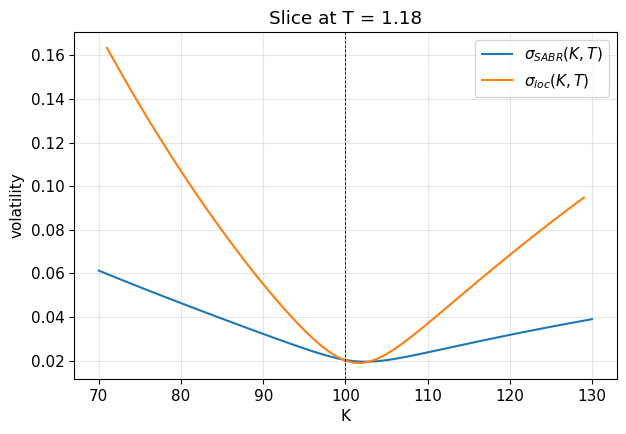

In [5]:
iT = len(Ts) // 2
plt.figure()
plt.plot(Ks, iv_surface[iT],  label=r'$\sigma_{SABR}(K,T)$')
plt.plot(Ks, sloc[iT],        label=r'$\sigma_{loc}(K,T)$')
plt.axvline(F, color='k', lw=0.6, ls='--')
plt.xlabel('K'); plt.ylabel('volatility')
plt.title(f'Slice at T = {Ts[iT]:.2f}')
plt.legend(); plt.show()

## Summary
* Dupire estimator implemented via finite differences on $w(K,T)$.
* Unit test: flat BS surface ⇒ $\sigma_{loc}$ constant to machine precision.
* Applied to SABR surface: recovers a well-defined local-vol surface with roughly twice the slope of the implied-vol skew (Dupire rule).
* Module 5 will use this routine to demonstrate the **wrong dynamics** of local vol (market: smile shifts *up* with F; local vol: smile shifts *down*).